# Data Collection Notebook

## Step 1: Setup and Folder Structure

In [ ]:
import os
import time
import pandas as pd
import numpy as np
from datetime import datetime

# Create project folders
folders = ['data/raw', 'data/processed', 'data/odds', 'figures', 'notebooks', 'src']
for f in folders:
    os.makedirs(f, exist_ok=True)

Folders created.
Current time: 2026-05-19 11:20


## Step 2: Pull Game Logs
One row per team per game. A single game = two rows (home and away)

In [ ]:
from nba_api.stats.endpoints import leaguegamefinder

seasons = ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
all_games = []

for season in seasons:
    print(f'Pulling {season}: ', end=' ')
    try:
        gamefinder = leaguegamefinder.LeagueGameFinder(
            season_nullable=season,
            season_type_nullable='Regular Season',
            league_id_nullable='00'
        )
        games = gamefinder.get_data_frames()[0]
        games['SEASON'] = season
        all_games.append(games)
        print(f'{len(games)} rows')
    except Exception as e:
        print(f'FAILED: {e}')
    time.sleep(2)  # rate limit

df_games = pd.concat(all_games, ignore_index=True)
df_games.to_csv('data/raw/nba_game_logs.csv', index=False)
print(f'\nTotal rows saved: {len(df_games)}')

Pulling 2018-19:  2460 rows
Pulling 2019-20:  2118 rows
Pulling 2020-21:  2160 rows
Pulling 2021-22:  2460 rows
Pulling 2022-23:  2460 rows
Pulling 2023-24:  2460 rows

Total rows saved: 14118


## Step 3: Sanity Check Game Logs

In [ ]:
print('ROWS PER SEASON: ')
print(df_games.groupby('SEASON').size())
print()

=== ROWS PER SEASON ===
SEASON
2018-19    2460
2019-20    2118
2020-21    2160
2021-22    2460
2022-23    2460
2023-24    2460
dtype: int64



In [ ]:
print('COLUMNS: ')
print(df_games.columns.tolist())
print()

=== COLUMNS ===
['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS', 'SEASON']



In [ ]:
print('MISSING VALUES: ')
missing = df_games.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values')
print()

=== MISSING VALUES ===
FT_PCT    1
dtype: int64



In [ ]:
# Parse dates
df_games['GAME_DATE'] = pd.to_datetime(df_games['GAME_DATE'])
print(f'Date range: {df_games["GAME_DATE"].min()} to {df_games["GAME_DATE"].max()}')
print()

Date range: 2018-10-16 00:00:00 to 2024-04-14 00:00:00



In [ ]:
# Flag bubble games (2019-20 after July 2020, no home court)
df_games['IS_BUBBLE'] = (
    (df_games['SEASON'] == '2019-20') & 
    (df_games['GAME_DATE'] > '2020-07-01')
)
print(f'Bubble game rows: {df_games["IS_BUBBLE"].sum()}')
print(f'Non-bubble game rows: {(~df_games["IS_BUBBLE"]).sum()}')

# Re-save with bubble flag
df_games.to_csv('data/raw/nba_game_logs.csv', index=False)
print('\nGame logs saved with bubble flag.')

Bubble game rows: 176
Non-bubble game rows: 13942

Game logs saved with bubble flag.


## Step 4: Pull Play-by-Play Data

In [ ]:
# Unique Game IDs for target seasons (excluding bubble games)
target_seasons = ['2022-23', '2023-24']
game_ids = df_games[
    (df_games['SEASON'].isin(target_seasons)) & 
    (~df_games['IS_BUBBLE'])
]['GAME_ID'].unique()

print(f'Total unique games to pull: {len(game_ids)}')
print(f'Estimated time at 1 sec/game: {len(game_ids)//60} minutes')

Total unique games to pull: 2460
Estimated time at 1 sec/game: 41 minutes


In [39]:
from nba_api.stats.endpoints import playbyplayv3
import time
from datetime import datetime, timedelta

remaining_seasons = ['2018-19', '2019-20', '2020-21', '2021-22']
remaining_ids = df_games[
    (df_games['SEASON'].isin(remaining_seasons)) & 
    (~df_games['IS_BUBBLE'])
]['GAME_ID'].unique()

print(f'Games to pull: {len(remaining_ids)}')
print(f'Started at: {datetime.now().strftime("%H:%M:%S")}')

all_pbp_extra = []
failed_extra = []
start_time = time.time()

for i, game_id in enumerate(remaining_ids):
    if i % 50 == 0 and i > 0:
        elapsed = time.time() - start_time
        per_game = elapsed / i
        remaining = per_game * (len(remaining_ids) - i)
        eta = datetime.now() + timedelta(seconds=remaining)
        print(f'Progress: {i}/{len(remaining_ids)} ({i/len(remaining_ids)*100:.0f}%) | '
              f'Elapsed: {elapsed/60:.0f}min | '
              f'ETA: {eta.strftime("%H:%M:%S")} | '
              f'Failed so far: {len(failed_extra)}')
    elif i == 0:
        print(f'Progress: 0/{len(remaining_ids)} (0%)')
    
    try:
        pbp = playbyplayv3.PlayByPlayV3(game_id=game_id)
        pbp_df = pbp.get_data_frames()[0]
        pbp_df['GAME_ID'] = game_id
        all_pbp_extra.append(pbp_df)
    except Exception as e:
        failed_extra.append((game_id, str(e)))
    time.sleep(1)

total_time = (time.time() - start_time) / 60
print(f'\nDone in {total_time:.0f} minutes. Pulled {len(all_pbp_extra)} games. Failed: {len(failed_extra)}')

df_pbp_extra = pd.concat(all_pbp_extra, ignore_index=True)
df_pbp_extra.to_csv('data/raw/nba_pbp_extra.csv', index=False)
print(f'Saved: {len(df_pbp_extra)} rows')

Games to pull: 4511
Started at: 11:20:35
Progress: 0/4511 (0%)
Progress: 50/4511 (1%) | Elapsed: 1min | ETA: 13:22:02 | Failed so far: 0
Progress: 100/4511 (2%) | Elapsed: 3min | ETA: 13:21:50 | Failed so far: 0
Progress: 150/4511 (3%) | Elapsed: 4min | ETA: 13:26:34 | Failed so far: 0
Progress: 200/4511 (4%) | Elapsed: 6min | ETA: 13:25:44 | Failed so far: 0
Progress: 250/4511 (6%) | Elapsed: 7min | ETA: 13:29:11 | Failed so far: 0
Progress: 300/4511 (7%) | Elapsed: 9min | ETA: 13:32:51 | Failed so far: 0
Progress: 350/4511 (8%) | Elapsed: 11min | ETA: 13:38:06 | Failed so far: 0
Progress: 400/4511 (9%) | Elapsed: 12min | ETA: 13:38:28 | Failed so far: 0
Progress: 450/4511 (10%) | Elapsed: 14min | ETA: 13:42:30 | Failed so far: 1
Progress: 500/4511 (11%) | Elapsed: 16min | ETA: 13:40:54 | Failed so far: 1
Progress: 550/4511 (12%) | Elapsed: 17min | ETA: 13:39:51 | Failed so far: 1
Progress: 600/4511 (13%) | Elapsed: 18min | ETA: 13:38:36 | Failed so far: 1
Progress: 650/4511 (14%) | E

In [40]:
df_pbp = pd.concat(all_pbp, ignore_index=True)
df_pbp.to_csv('data/raw/nba_pbp.csv', index=False)
print(f'Play-by-play rows saved: {len(df_pbp)}')
print(f'Columns: {df_pbp.columns.tolist()}')

# Preview score columns
sample_game = df_pbp['GAME_ID'].iloc[0]
sample = df_pbp[df_pbp['GAME_ID'] == sample_game].head(20)
print('\n=== SAMPLE GAME (first 20 events) ===')
print(sample[['GAME_ID', 'period', 'clock', 'scoreHome', 'scoreAway', 'description']].to_string())

Play-by-play rows saved: 1202490
Columns: ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId', 'GAME_ID']

=== SAMPLE GAME (first 20 events) ===
       GAME_ID  period        clock scoreHome scoreAway                                               description
0   0022201218       1  PT12M00.00S         0         0                         Start of 1st Period (1:11 PM EST)
1   0022201218       1  PT12M00.00S                                  Jump Ball Allen vs. Williams: Tip to Maledon
2   0022201218       1  PT11M39.00S                                                   MISS McGowens 3PT Jump Shot
3   0022201218       1  PT11M36.00S                                                   Allen REBOUND (Off:0 Def:1)
4   0022201218       1 

## Step 5: Sanity Check Play-by-Play

In [41]:
# Preview score columns
print('=== SCORE COLUMNS ===')
score_cols = [c for c in df_pbp.columns if 'score' in c.lower()]
print(score_cols)
print()

# Preview a single game
sample_game = df_pbp['GAME_ID'].iloc[0]
sample = df_pbp[df_pbp['GAME_ID'] == sample_game].head(20)
print('=== SAMPLE GAME (first 20 events) ===')
print(sample[['GAME_ID', 'period', 'clock', 'scoreHome', 'scoreAway', 'description']].to_string())

=== SCORE COLUMNS ===
['scoreHome', 'scoreAway']

=== SAMPLE GAME (first 20 events) ===
       GAME_ID  period        clock scoreHome scoreAway                                               description
0   0022201218       1  PT12M00.00S         0         0                         Start of 1st Period (1:11 PM EST)
1   0022201218       1  PT12M00.00S                                  Jump Ball Allen vs. Williams: Tip to Maledon
2   0022201218       1  PT11M39.00S                                                   MISS McGowens 3PT Jump Shot
3   0022201218       1  PT11M36.00S                                                   Allen REBOUND (Off:0 Def:1)
4   0022201218       1  PT11M33.00S                      Rubio Out of Bounds - Bad Pass Turnover Turnover (P1.T1)
5   0022201218       1  PT11M16.00S                                             MISS Mykhailiuk 31' 3PT Jump Shot
6   0022201218       1  PT11M12.00S                                                    Wade REBOUND (Off:0 Def:1)


## Step 6: Parse Game States at 2-Minute Intervals
From the play-by-play, extract the score margin at every 2-minute mark.

NBA regulation = 4 quarters x 12 minutes = 48 minutes = 2880 seconds.

We sample at: 2880, 2760, 2640, ..., 120, 0 seconds remaining. That is 24 snapshots per game.

In [42]:
# Parse V3 columns into the format the rest of the notebook expects
def parse_clock_v3(period, clock_str):
    try:
        clean = str(clock_str).replace('PT', '').replace('S', '')
        parts = clean.split('M')
        minutes = int(parts[0])
        seconds = float(parts[1])
        clock_seconds = minutes * 60 + int(seconds)
        
        if period <= 4:
            total_remaining = (4 - period) * 720 + clock_seconds
        else:
            total_remaining = -((period - 5) * 300 + (300 - clock_seconds))
        return total_remaining
    except:
        return None

def compute_margin_v3(score_home, score_away):
    try:
        return int(score_home) - int(score_away)
    except:
        return None

print('Parsing time remaining and score margins...')
df_pbp['SECONDS_REMAINING'] = df_pbp.apply(
    lambda row: parse_clock_v3(row['period'], row['clock']), axis=1
)
df_pbp['MARGIN_INT'] = df_pbp.apply(
    lambda row: compute_margin_v3(row['scoreHome'], row['scoreAway']), axis=1
)

print(f'Parsed rows with valid time: {df_pbp["SECONDS_REMAINING"].notna().sum()}')
print(f'Parsed rows with valid margin: {df_pbp["MARGIN_INT"].notna().sum()}')

Parsing time remaining and score margins...
Parsed rows with valid time: 1202490
Parsed rows with valid margin: 318665


In [43]:
# Quick sanity check on the computed margin
print(f'Margin range: {df_pbp["MARGIN_INT"].min()} to {df_pbp["MARGIN_INT"].max()}')
print(f'Null margins: {df_pbp["MARGIN_INT"].isnull().sum()}')
print(f'\nSample values:')
print(df_pbp[['GAME_ID', 'period', 'clock', 'scoreHome', 'scoreAway', 'MARGIN_INT', 'SECONDS_REMAINING']].dropna().head(10).to_string())

Margin range: -59.0 to 62.0
Null margins: 883825

Sample values:
       GAME_ID  period        clock scoreHome scoreAway  MARGIN_INT  SECONDS_REMAINING
0   0022201218       1  PT12M00.00S         0         0         0.0               2880
7   0022201218       1  PT10M57.00S         2         0         2.0               2817
10  0022201218       1  PT10M35.00S         5         0         5.0               2795
19  0022201218       1  PT09M27.00S         7         0         7.0               2727
20  0022201218       1  PT09M11.00S         7         2         5.0               2711
42  0022201218       1  PT06M28.00S        10         2         8.0               2548
46  0022201218       1  PT06M03.00S        10         4         6.0               2523
53  0022201218       1  PT05M23.00S        10         6         4.0               2483
65  0022201218       1  PT04M16.00S        12         6         6.0               2416
68  0022201218       1  PT03M53.00S        12         8         4

In [44]:
print('Parsing time remaining and score margins...')
df_pbp['SECONDS_REMAINING'] = df_pbp.apply(
    lambda row: parse_clock_v3(row['period'], row['clock']), axis=1
)
df_pbp['MARGIN_INT'] = df_pbp.apply(
    lambda row: compute_margin_v3(row['scoreHome'], row['scoreAway']), axis=1
)

print(f'Parsed rows with valid time: {df_pbp["SECONDS_REMAINING"].notna().sum()}')
print(f'Parsed rows with valid margin: {df_pbp["MARGIN_INT"].notna().sum()}')

Parsing time remaining and score margins...
Parsed rows with valid time: 1202490
Parsed rows with valid margin: 318665


In [45]:
# Build game outcome lookup: for each GAME_ID, did the home team win?
# In the game logs, MATCHUP contains 'vs.' for home and '@' for away
home_games = df_games[
    (df_games['MATCHUP'].str.contains('vs.')) &
    (df_games['SEASON'].isin(target_seasons)) &
    (~df_games['IS_BUBBLE'])
][['GAME_ID', 'WL', 'TEAM_ABBREVIATION']].copy()

home_games['HOME_WIN'] = (home_games['WL'] == 'W').astype(int)
home_games = home_games.rename(columns={'TEAM_ABBREVIATION': 'HOME_TEAM'})

outcome_lookup = home_games.set_index('GAME_ID')['HOME_WIN'].to_dict()

print(f'Home wins: {sum(outcome_lookup.values())} / {len(outcome_lookup)}')
print(f'Home win rate: {sum(outcome_lookup.values()) / len(outcome_lookup):.3f}')

Home wins: 1382 / 2460
Home win rate: 0.562


In [46]:
# Sample game state at 2-minute intervals
# For each game, find the last event before each 2-min mark

snapshot_times = list(range(2880, -1, -120))  # 2880, 2760, ..., 120, 0

snapshots = []
game_ids_in_pbp = df_pbp['GAME_ID'].unique()

print(f'Processing {len(game_ids_in_pbp)} games...')

for i, gid in enumerate(game_ids_in_pbp):
    if i % 500 == 0:
        print(f'  {i}/{len(game_ids_in_pbp)}')
    
    game = df_pbp[
        (df_pbp['GAME_ID'] == gid) & 
        (df_pbp['MARGIN_INT'].notna()) &
        (df_pbp['SECONDS_REMAINING'].notna()) &
        (df_pbp['SECONDS_REMAINING'] >= 0)  # regulation only
    ].sort_values('SECONDS_REMAINING', ascending=False)
    
    if len(game) == 0:
        continue
    
    home_win = outcome_lookup.get(gid)
    if home_win is None:
        continue
    
    for t in snapshot_times:
        # Find the last event at or just after this time mark
        events_at_or_before = game[game['SECONDS_REMAINING'] <= t]
        
        if len(events_at_or_before) == 0:
            # Game hasn't reached this point yet or no scored events
            # Use the earliest event's margin (usually 0 for game start)
            if t == 2880:
                snapshots.append({
                    'GAME_ID': gid,
                    'SECONDS_REMAINING': t,
                    'SCORE_MARGIN': 0,
                    'HOME_WIN': home_win
                })
            continue
        
        closest = events_at_or_before.iloc[0]  # highest seconds_remaining <= t
        
        snapshots.append({
            'GAME_ID': gid,
            'SECONDS_REMAINING': t,
            'SCORE_MARGIN': closest['MARGIN_INT'],
            'HOME_WIN': home_win
        })

df_snapshots = pd.DataFrame(snapshots)
print(f'\nTotal snapshots: {len(df_snapshots)}')
print(f'Unique games: {df_snapshots["GAME_ID"].nunique()}')
print(f'Snapshots per game: ~{len(df_snapshots) / df_snapshots["GAME_ID"].nunique():.0f}')

Processing 2460 games...
  0/2460
  500/2460
  1000/2460
  1500/2460
  2000/2460

Total snapshots: 61500
Unique games: 2460
Snapshots per game: ~25


In [47]:
# Quick sanity: at time 2880 (game start), margin should almost always be 0
start_margins = df_snapshots[df_snapshots['SECONDS_REMAINING'] == 2880]['SCORE_MARGIN']
print(f'Margin at game start - mean: {start_margins.mean():.2f}, std: {start_margins.std():.2f}')
print('(Should be ~0 with low std)\n')

# At time 0 (game end), margin should correlate with outcome
end = df_snapshots[df_snapshots['SECONDS_REMAINING'] == 0].copy()
print(f'At game end:')
print(f'  Home wins - mean margin: {end[end["HOME_WIN"]==1]["SCORE_MARGIN"].mean():.1f}')
print(f'  Home losses - mean margin: {end[end["HOME_WIN"]==0]["SCORE_MARGIN"].mean():.1f}')
print('(Winners should have positive margin, losers negative)')

Margin at game start - mean: 0.00, std: 0.04
(Should be ~0 with low std)

At game end:
  Home wins - mean margin: 12.3
  Home losses - mean margin: -10.6
(Winners should have positive margin, losers negative)


In [48]:
# Save the snapshot dataset
df_snapshots.to_csv('data/processed/game_snapshots.csv', index=False)
print('Saved: data/processed/game_snapshots.csv')
print(df_snapshots.head(10))

Saved: data/processed/game_snapshots.csv
      GAME_ID  SECONDS_REMAINING  SCORE_MARGIN  HOME_WIN
0  0022201218               2880           0.0         0
1  0022201218               2760           7.0         0
2  0022201218               2640           8.0         0
3  0022201218               2520           4.0         0
4  0022201218               2400           4.0         0
5  0022201218               2280           7.0         0
6  0022201218               2160           8.0         0
7  0022201218               2040           5.0         0
8  0022201218               1920           6.0         0
9  0022201218               1800          10.0         0


## Step 7: Bin the Data for GP Training
Group snapshots into (score_margin, time_remaining) bins and compute empirical win rates.
This reduces ~50k observations to ~2000 bins, which the GP can handle.

In [49]:
# Separate train and test by season
# We need the season info - merge from game logs
game_season = df_games[['GAME_ID', 'SEASON']].drop_duplicates()
df_snapshots = df_snapshots.merge(game_season, on='GAME_ID', how='left')

df_train = df_snapshots[df_snapshots['SEASON'] == '2022-23'].copy()
df_test = df_snapshots[df_snapshots['SEASON'] == '2023-24'].copy()

print(f'Training snapshots (2022-23): {len(df_train)}')
print(f'Test snapshots (2023-24): {len(df_test)}')

Training snapshots (2022-23): 30750
Test snapshots (2023-24): 30750


In [50]:
# Bin: score margin in 2-point bins from -30 to +30, time in 2-min (120s) bins
margin_bins = np.arange(-30, 32, 2)  # -30, -28, ..., 28, 30
time_bins = np.arange(0, 2881, 120)  # 0, 120, ..., 2760, 2880

df_train['MARGIN_BIN'] = pd.cut(
    df_train['SCORE_MARGIN'].clip(-30, 30), 
    bins=margin_bins, 
    labels=margin_bins[:-1] + 1,  # bin center
    include_lowest=True
)
df_train['TIME_BIN'] = pd.cut(
    df_train['SECONDS_REMAINING'], 
    bins=time_bins, 
    labels=time_bins[:-1] + 60,  # bin center
    include_lowest=True
)

# Compute empirical win rate per bin
binned = df_train.groupby(['MARGIN_BIN', 'TIME_BIN']).agg(
    win_rate=('HOME_WIN', 'mean'),
    count=('HOME_WIN', 'count')
).reset_index()

# Drop bins with fewer than 5 observations (noisy)
binned = binned[binned['count'] >= 5].copy()
binned['MARGIN_BIN'] = binned['MARGIN_BIN'].astype(float)
binned['TIME_BIN'] = binned['TIME_BIN'].astype(float)

print(f'Total bins: {len(binned)}')
print(f'Min observations per bin: {binned["count"].min()}')
print(f'Mean observations per bin: {binned["count"].mean():.1f}')
print(f'\nWin rate range: {binned["win_rate"].min():.3f} to {binned["win_rate"].max():.3f}')

binned.to_csv('data/processed/binned_train.csv', index=False)
print('\nSaved: data/processed/binned_train.csv')

Total bins: 589
Min observations per bin: 5
Mean observations per bin: 52.0

Win rate range: 0.000 to 1.000

Saved: data/processed/binned_train.csv


C:\Users\Josh\AppData\Local\Temp\ipykernel_75788\212064309.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = df_train.groupby(['MARGIN_BIN', 'TIME_BIN']).agg(


## Step 8: Quick EDA Plots
Visual confirmation that the data makes sense before moving on.

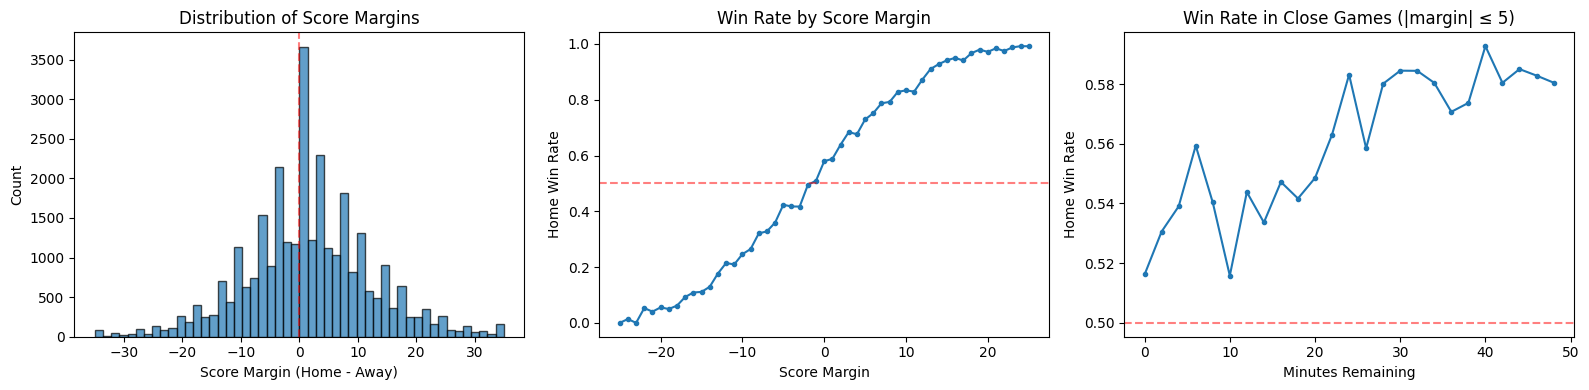

Saved: figures/01_eda_checks.png


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Distribution of score margins across all snapshots
axes[0].hist(df_train['SCORE_MARGIN'].clip(-35, 35), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Score Margin (Home - Away)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Score Margins')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Plot 2: Win rate by score margin (averaged across all times)
margin_wr = df_train.groupby(
    df_train['SCORE_MARGIN'].clip(-25, 25)
)['HOME_WIN'].mean()
axes[1].plot(margin_wr.index, margin_wr.values, 'o-', markersize=3)
axes[1].set_xlabel('Score Margin')
axes[1].set_ylabel('Home Win Rate')
axes[1].set_title('Win Rate by Score Margin')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

# Plot 3: Win rate by time remaining (for close games only, margin -5 to 5)
close = df_train[df_train['SCORE_MARGIN'].between(-5, 5)]
time_wr = close.groupby('SECONDS_REMAINING')['HOME_WIN'].mean()
axes[2].plot(time_wr.index / 60, time_wr.values, 'o-', markersize=3)
axes[2].set_xlabel('Minutes Remaining')
axes[2].set_ylabel('Home Win Rate')
axes[2].set_title('Win Rate in Close Games (|margin| ≤ 5)')
axes[2].axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/01_eda_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/01_eda_checks.png')

## Step 9: Heatmap Preview of Binned Win Rates
This is a preview of what the GP will model. If this looks reasonable, the data is ready.

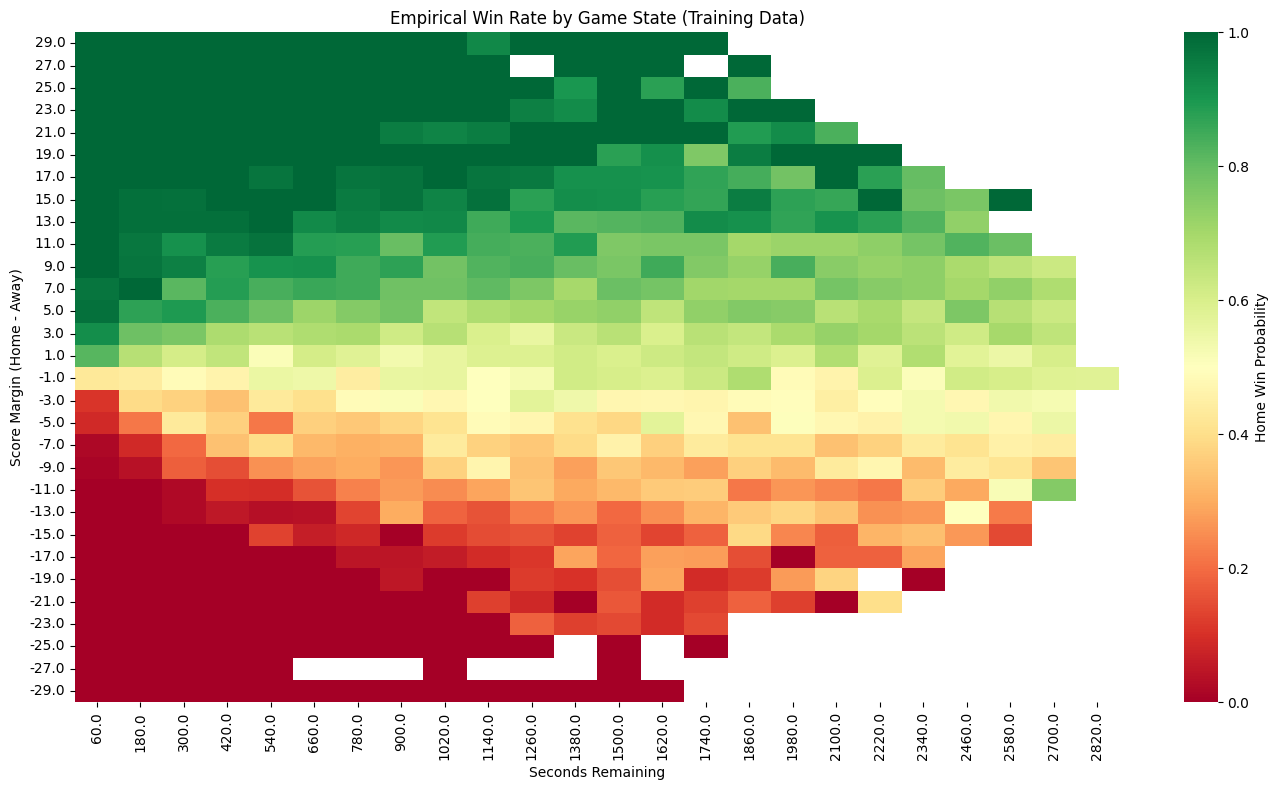

Saved: figures/01_empirical_winrate_heatmap.png


In [52]:
# Pivot binned data into a heatmap
heatmap_data = binned.pivot(index='MARGIN_BIN', columns='TIME_BIN', values='win_rate')

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data.sort_index(ascending=False), 
    cmap='RdYlGn', 
    center=0.5,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Home Win Probability'}
)
plt.xlabel('Seconds Remaining')
plt.ylabel('Score Margin (Home - Away)')
plt.title('Empirical Win Rate by Game State (Training Data)')
plt.tight_layout()
plt.savefig('figures/01_empirical_winrate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/01_empirical_winrate_heatmap.png')

In [53]:
train_games = df_snapshots[df_snapshots['SEASON'] == '2022-23']['GAME_ID'].nunique()
test_games = df_snapshots[df_snapshots['SEASON'] == '2023-24']['GAME_ID'].nunique()
print(f'Training games: {train_games} (expect ~1230)')
print(f'Test games: {test_games} (expect ~1230)')
print(f'Any overlap: {len(set(df_snapshots[df_snapshots["SEASON"]=="2022-23"]["GAME_ID"]) & set(df_snapshots[df_snapshots["SEASON"]=="2023-24"]["GAME_ID"]))}')

Training games: 1230 (expect ~1230)
Test games: 1230 (expect ~1230)
Any overlap: 0


## Morning Checkpoint

**You should now have:**
- `data/raw/nba_game_logs.csv` - all game logs with bubble flag
- `data/raw/nba_pbp.csv` - play-by-play for 2022-23 and 2023-24
- `data/processed/game_snapshots.csv` - 2-min interval snapshots with outcomes
- `data/processed/binned_train.csv` - GP-ready binned win rates
- `figures/01_eda_checks.png` - sanity check plots
- `figures/01_empirical_winrate_heatmap.png` - preview of what GP will model

**If the heatmap shows:**
- Green (high win rate) at positive margins → correct
- Red (low win rate) at negative margins → correct
- More extreme colors at low seconds remaining → correct (late game margins are more decisive)
- Yellow band near margin=0 → correct (toss-up games)

**If it looks right, move to the afternoon: baselines and GP fitting.**